**Sales Trend And Time Based Performance Analysis bold text for Afficionado Coffee Roasters**

*Step 1:Data Analysis and Validation*

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
uploaded=files.upload()
data=pd.read_csv("Afficionado Coffee Roasters.xlsx - Transactions.csv")
df=pd.DataFrame(data)



Saving Afficionado Coffee Roasters.xlsx - Transactions.csv to Afficionado Coffee Roasters.xlsx - Transactions (2).csv


In [16]:
df.head()
df.tail()
df.shape
df.dtypes
df.info()
df.columns
df.isna().sum()
df.duplicated().unique()
df["transaction_id"].duplicated().unique()
(df['unit_price']<=0).unique
(df['transaction_qty']<=0).sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 12.5+ MB


np.int64(0)

*Step 2: Feature Engineering*

In [17]:
df['revenue']=df['unit_price']*df['transaction_qty']
df['transaction_time']=pd.to_datetime(df['transaction_time'])
df['hour']=df['transaction_time'].dt.hour
#here only transaction time is given but transaction date is not given
#so converting to datetime will default add current date
print(df['hour'].unique())
print(df['year'].unique())
df['transaction_time'].unique()
def time_bucket(hour):
  if 6<=hour<=11:
    return "morning"
  elif 12<=hour<=16:
    return "afternoon"
  elif 17<=hour<=21:
    return "evening"
  else:
    return "night"
df['time_bucket']=df['hour'].apply(time_bucket)
print(df['time_bucket'].unique())
print(df[['hour','time_bucket']].nunique())
print(df['store_location'].unique())
print(df['store_location'].value_counts())

/tmp/ipykernel_16538/4075078329.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['transaction_time']=pd.to_datetime(df['transaction_time'])


[ 7  8  9 10 11 12 13 14 15 16 17 18 19  6 20]
[2025]
['morning' 'afternoon' 'evening']
hour           15
time_bucket     3
dtype: int64
['Lower Manhattan' "Hell's Kitchen" 'Astoria']
store_location
Hell's Kitchen     50735
Astoria            50599
Lower Manhattan    47782
Name: count, dtype: int64


*Step 3: Summary Statistics*

In [18]:
print(df.describe())
df['revenue'].max()
df['revenue'].min()
print(df[['store_location','product_category','revenue']].max())
print(df[['store_location','product_category','revenue']].min())


       transaction_id      year               transaction_time  \
count   149116.000000  149116.0                         149116   
mean     74737.371872    2025.0  2026-03-15 12:14:15.815794688   
min          1.000000    2025.0            2026-03-15 06:00:00   
25%      37335.750000    2025.0     2026-03-15 09:05:10.500000   
50%      74727.500000    2025.0            2026-03-15 11:15:28   
75%     112094.250000    2025.0            2026-03-15 15:25:57   
max     149456.000000    2025.0            2026-03-15 20:59:32   
std      43153.600016       0.0                            NaN   

       transaction_qty       store_id     product_id     unit_price  \
count    149116.000000  149116.000000  149116.000000  149116.000000   
mean          1.438276       5.342063      47.918607       3.382219   
min           1.000000       3.000000       1.000000       0.800000   
25%           1.000000       3.000000      33.000000       2.500000   
50%           1.000000       5.000000      47.0000

*Step 4: Time Based Analysis and Visualisation*

    hour   revenue
0      6  21900.27
1      7  63526.47
2      8  82699.87
3      9  85169.53
4     10  88673.39
5     11  46319.14
6     12  40192.79
7     13  40367.45
8     14  41304.74
9     15  41733.10
10    16  41122.75
11    17  40134.31
12    18  34286.20
13    19  28446.68
14    20   2935.64
    hour  transaction_id
0      6            4594
1      7           13428
2      8           17654
3      9           17764
4     10           18545
5     11            9766
6     12            8708
7     13            8714
8     14            8933
9     15            8979
10    16            9093
11    17            8745
12    18            7498
13    19            6092
14    20             603
  time_bucket    revenue
0   afternoon  204720.83
1     evening  105802.83
2     morning  388288.67


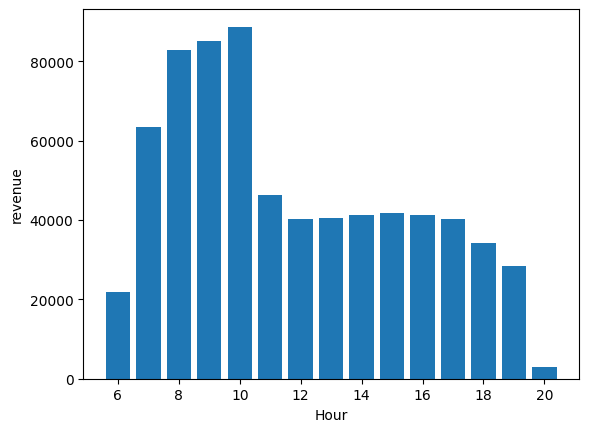

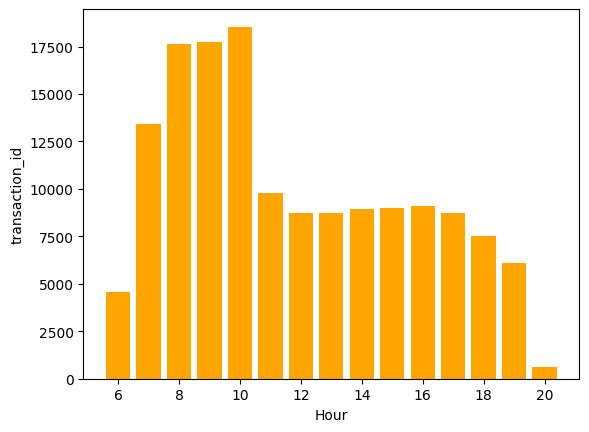

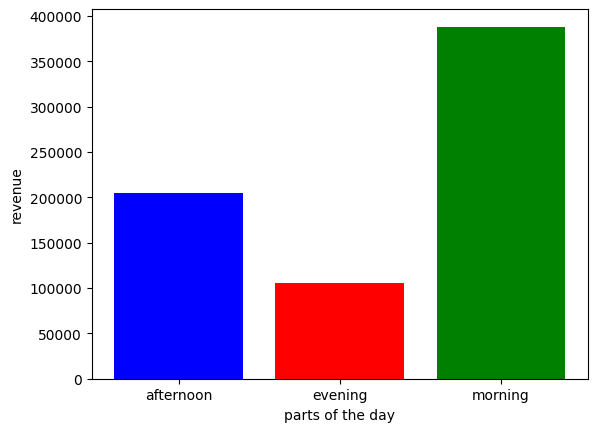

In [19]:
hour_revenue=df.groupby('hour')['revenue'].sum().reset_index()
print(hour_revenue)
hour_transaction =df.groupby('hour')['transaction_id'].count().reset_index()
print(hour_transaction)
time_bucket_revenue=df.groupby('time_bucket')['revenue'].sum().reset_index()
print(time_bucket_revenue)
plt.bar(hour_revenue['hour'],hour_revenue['revenue'])
plt.xlabel("Hour")
plt.ylabel("revenue")
plt.show()
plt.bar(hour_transaction['hour'],hour_transaction['transaction_id'],color="orange")
plt.xlabel("Hour")
plt.ylabel("transaction_id")
plt.show()
plt.bar(time_bucket_revenue['time_bucket'],time_bucket_revenue['revenue'],color=["blue","red","green","yellow"])
plt.xlabel("parts of the day")
plt.ylabel("revenue")
plt.show()

Step 5: Product Revenue Analysis

     product_category    revenue
0              Bakery   82315.64
1             Branded   13607.00
2              Coffee  269952.45
3        Coffee beans   40085.25
4  Drinking Chocolate   72416.00
5            Flavours    8408.80
6           Loose Tea   11213.60
7  Packaged Chocolate    4407.64
8                 Tea  196405.95


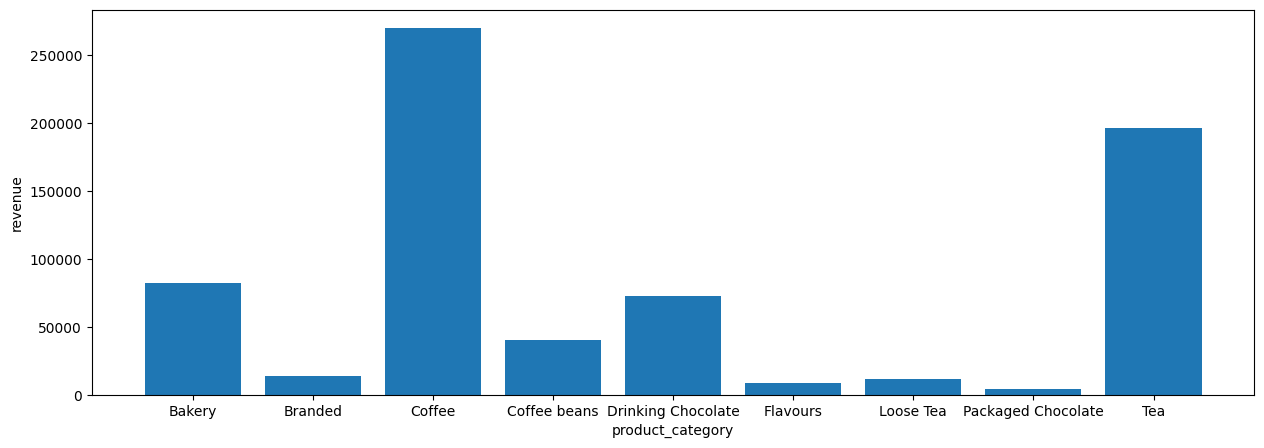

In [20]:
product_revenue=df.groupby("product_category")['revenue'].sum().reset_index()
print(product_revenue)
plt.figure(figsize=(15,5))
plt.bar(product_revenue["product_category"],product_revenue['revenue'])
plt.xlabel("product_category")
plt.ylabel("revenue")
plt.show()

Step 6: store Vs revenue heatmap

hour                   6         7         8         9         10        11  \
store_location                                                                
Astoria              0.00  19028.80  22805.90  23183.57  24426.12  15498.13   
Hell's Kitchen    7531.17  15961.05  31544.44  32874.29  33605.81  17926.54   
Lower Manhattan  14369.10  28536.62  28349.53  29111.67  30641.46  12894.47   

hour                   12        13        14        15        16        17  \
store_location                                                                
Astoria          15681.20  15947.87  15175.27  15651.95  16110.85  15839.30   
Hell's Kitchen   11343.10  12070.10  12297.50  11311.25  11990.48  12789.50   
Lower Manhattan  13168.49  12349.48  13831.97  14769.90  13021.42  11505.51   

hour                   18        19       20  
store_location                                
Astoria          15951.30  16943.65     0.00  
Hell's Kitchen   11863.21  10766.36  2636.37  
Lower Manhattan   64

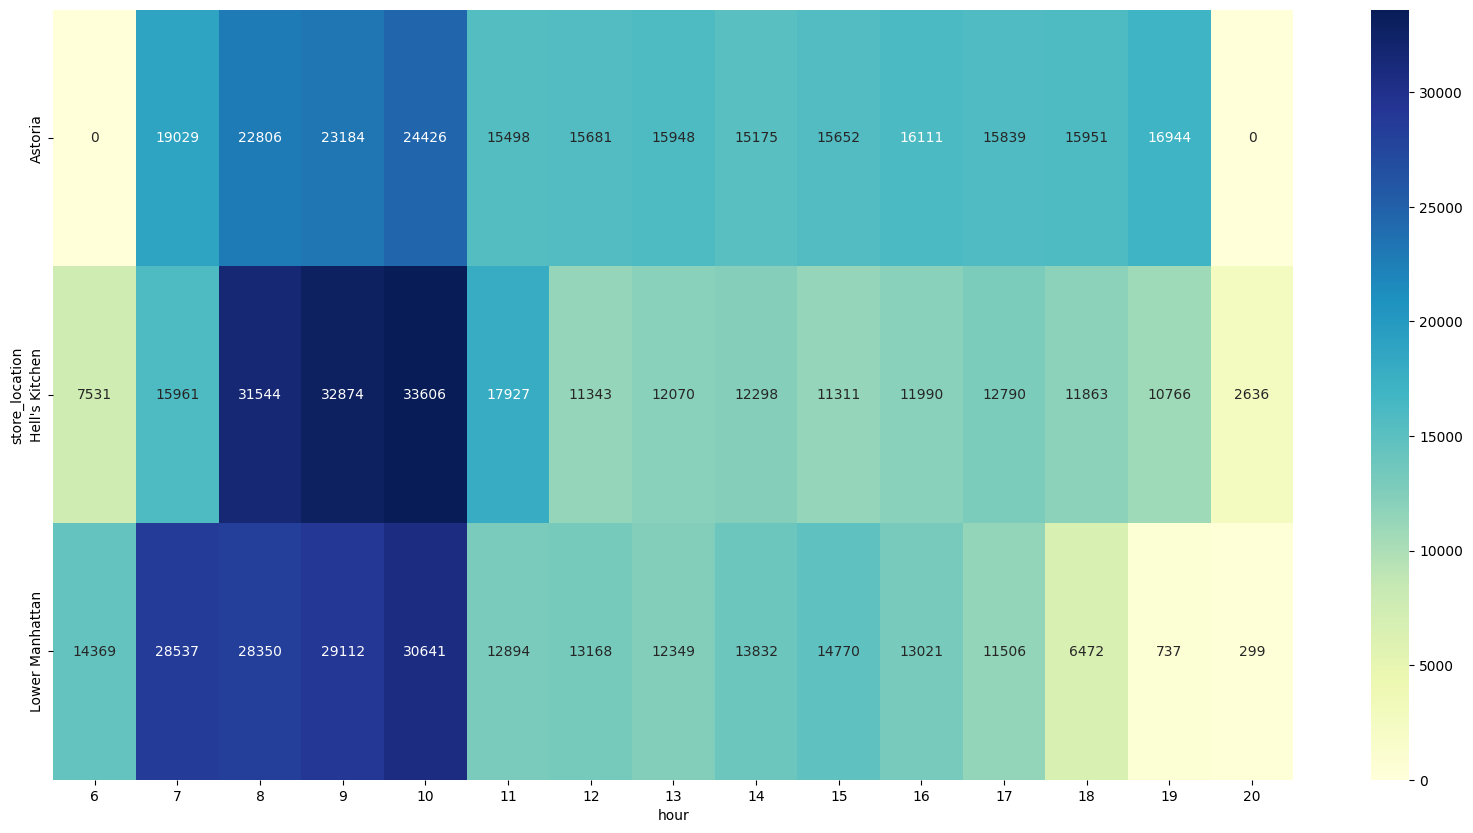

time_bucket      afternoon   evening    morning
store_location                                 
Astoria           78567.14  48734.25  104942.52
Hell's Kitchen    59012.43  38055.44  139443.30
Lower Manhattan   67141.26  19013.14  143902.85


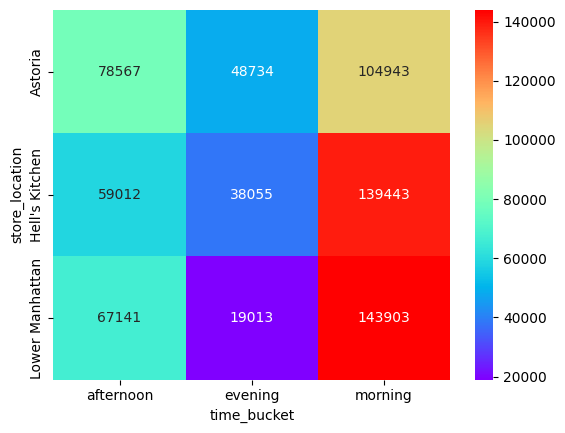

In [21]:
import seaborn as sns
plt.figure(figsize=(20,10))
store_revenue_pivot=pd.pivot_table(df,
                                   values="revenue",
                                   columns="hour",
                                   index="store_location",
                                   aggfunc="sum"
                                   )
store_revenue_pivot.fillna(0,inplace=True)
print(store_revenue_pivot)
sns.heatmap(store_revenue_pivot,annot=True,fmt=".0f",cmap="YlGnBu")
plt.show()
#based on the parts of the day
store_revenue=pd.pivot_table(df,
                             values="revenue",
                             index="store_location",
                             columns="time_bucket",
                             aggfunc="sum"
                             )
print(store_revenue)
sns.heatmap(store_revenue,annot=True,fmt=".0f",cmap="rainbow")
plt.show()

Step 7: Revenue Distribution

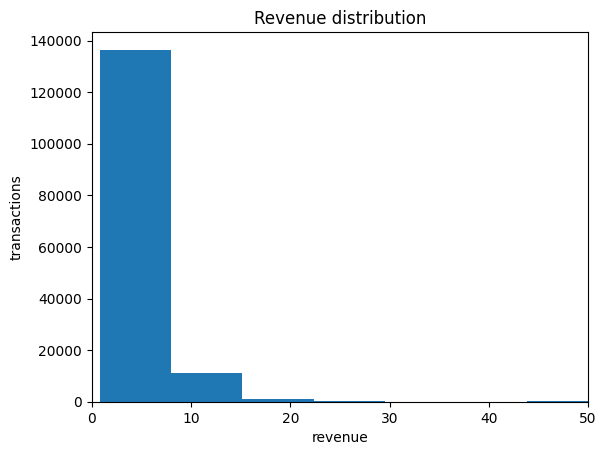

In [22]:
plt.hist(df["revenue"],bins=50)
plt.title("Revenue distribution")
plt.xlim(0,50)
plt.xlabel("revenue")
plt.ylabel("transactions")
plt.show()
#day based analysis is not possible because date column is not given in the dataset
df.to_csv("coffee_sales_clean.csv",index="False")